#### Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import scipy
import random
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from math import pi
from scipy.interpolate import NearestNDInterpolator

%matplotlib inline

#floris simulation modules
from floris.tools.wind_rose import WindRose
from floris.tools import FlorisInterface
import floris.tools.visualization as wakeviz
from floris.turbine_library import TurbineInterface, TurbineLibrary
from floris.tools.visualization import (
    calculate_horizontal_plane_with_turbines,
    visualize_cut_plane,
)

## Optimized Layouts

### WInd Rose

In [3]:
df_wind_montly = pd.read_csv('./2020_Daily_Avgs.csv')
df_wind_montly.head()

list_wd_bins = [0., 5., 10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60., 65., 70., 75., 80., 85., 90., 95., 100., 105., 110., 115., 120., 125., 130., 135., 140., 145., 150., 155., 160., 165., 170., 175., 180., 185., 190., 195., 200., 205., 210., 215., 220., 225., 230., 235., 240., 245., 250., 255., 260., 265., 270., 275., 280., 285., 290., 295., 300., 305., 310., 315., 320., 325., 330., 335., 340., 345., 350., 355.]

list_ws_bins = [0., 1., 2., 3., 4., 5., 6., 7., 8., 9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.]

windr = WindRose()

df_wind_calc = windr.make_wind_rose_from_user_data(wd_raw=df_wind_montly['average_wind_dir_deg'], ws_raw=df_wind_montly['Factorized_Mean'], wd=np.array(list_wd_bins), ws=np.array(list_ws_bins))


wd_array = np.array(df_wind_calc["wd"].unique(), dtype=float)
ws_array = np.array(df_wind_calc["ws"].unique(), dtype=float)


wd_grid, ws_grid = np.meshgrid(wd_array, ws_array, indexing="ij")
freq_interp = NearestNDInterpolator(df_wind_calc[["wd", "ws"]], df_wind_calc["freq_val"])
freq = freq_interp(wd_grid, ws_grid)

# Normalize the frequency array to sum to exactly 1.0
freq = freq / np.sum(freq)

Correcting negative Overhang:-2.5


### Floris Interface

In [4]:
fi_nrel = FlorisInterface('./gch.yaml')
fi_vestas = FlorisInterface('./gch_vestas.yaml')

In [5]:
def aep_powers(fi, df):
    power_list = []
    fi.reinitialize(
        layout_x=df["Layout_x"],
        layout_y=df['Layout_y'],
        wind_directions=wd_array,
        wind_speeds=ws_array,
    )

    aep = fi.get_farm_AEP(
        freq=freq,
        cut_in_wind_speed=4.0,  # Wakes are not evaluated below this wind speed
        cut_out_wind_speed=25.0,  # Wakes are not evaluated above this wind speed
    )
    power_list.append(round((aep / 1.0e9), 3))

    aep_no_wake = fi.get_farm_AEP(freq, no_wake=True)
    power_list.append(round((aep_no_wake / 1.0e9), 3))

    percentage_power_loss = (aep_no_wake - aep) / aep_no_wake * 100
    power_list.append(round(percentage_power_loss, 3))


    return power_list

#### Defining Populations

#### Defining Parameters

In [6]:
tournament_size = 3
target_coverage_area = 800000
turbine_diameter = 52
mutation_rate = 0.8
crossover_rate = 0.1
population_size = 2
generations = 2
elitism = True

min_distance = 52
max_distance = turbine_diameter * 5
min_turbines = 25
max_turbines = 65

next_gen_population_size = 20

### The GA Implmentation

In [7]:
# Define the variables
initial_population_size = 20
min_turbines = 15
max_turbines = 21
turbine_diameter = 52 * 0.1  # Factor by 0.1
max_distance = turbine_diameter * 5
mutation_rate = 0.1
tournament_size = 5
next_gen_population_size = 10
target_coverage_area = 800000 * 0.1  # Factor by 0.1

def initialize_populations():
    global max_distance  # Make max_distance a global variable so we can modify it
    populations = []
    for _ in range(initial_population_size):  # Generate initial populations
        num_turbines = np.random.randint(min_turbines, max_turbines + 1)  # Randomly select the number of turbines
        layout = np.zeros((num_turbines, 2))  # Use NumPy array instead of DataFrame
        for i in range(1, num_turbines):
            while True:
                new_turbine = np.random.uniform(turbine_diameter, max_distance, size=(1, 2)) * 0.1  # Factor by 0.1
                if all(np.linalg.norm(layout[:i] - new_turbine, axis=1) >= turbine_diameter):
                    layout[i] = new_turbine
                    break
        # If the enclosed area is less than 100000, increase max_distance
        if calculate_enclosed_area(layout) < 100000:
            max_distance *= 1.1  # Increase max_distance by 10%
        populations.append(layout)
    return populations

def calculate_fitness(layout):
    num_turbines = len(layout)
    distances = scipy.spatial.distance.pdist(layout)
    wake_effect = np.sum(1 / distances)
    return num_turbines - wake_effect

def tournament_selection(populations):
    tournament = random.sample(populations, tournament_size)
    return max(tournament, key=calculate_fitness)

def crossover(parent1, parent2):
    num_turbines = min(len(parent1), len(parent2))  # Use the smaller number of turbines
    child = parent1[:num_turbines].copy()
    random_mask = np.random.rand(num_turbines) < 0.5  # Create the mask with the size of the child
    child[random_mask] = parent1[:num_turbines][random_mask]
    child[~random_mask] = parent2[:num_turbines][~random_mask]
    return child

def mutate(layout):
    if np.random.rand() < mutation_rate:
        idx = np.random.choice(range(1, len(layout)))  # Do not mutate the turbine at the origin
        new_turbine = np.random.uniform(turbine_diameter, max_distance, size=(1, 2))
        if all(np.linalg.norm(layout[:idx] - new_turbine, axis=1) >= turbine_diameter):
            layout[idx] = new_turbine
    return layout

def calculate_enclosed_area(layout):
    hull = ConvexHull(layout)
    return hull.volume

def run_genetic_algorithm(populations):
    best_layout = None  # Initialize a variable to store the best layout

    for _ in range(next_gen_population_size):
        next_gen = []
        for _ in range(len(populations)):
            parent1 = tournament_selection(populations)
            parent2 = tournament_selection(populations)
            child = crossover(parent1, parent2)
            child = mutate(child)
            next_gen.append(child)
        populations = next_gen

    # Sort populations by fitness and enclosed area
    populations.sort(key=lambda p: (calculate_fitness(p), -calculate_enclosed_area(p)), reverse=True)

    # Update best_layout with the best layout
    for population in populations:
        if calculate_enclosed_area(population) <= target_coverage_area:
            best_layout = population
            break

    # If all layouts exceed 800,000 sq meters, return the one with the smallest area
    if best_layout is None:
        best_layout = min(populations, key=calculate_enclosed_area)

    return best_layout

def plot_best_layout(best_layout):
    fig, ax = plt.subplots(figsize=(5, 5))  # Adjust subplot configuration
    ax.scatter(best_layout[:, 0], best_layout[:, 1], c='b', s=200)
    plt.tight_layout()
    plt.show()

def main():
    populations = initialize_populations()
    best_layout = run_genetic_algorithm(populations)  # Get only the best layout

    plot_best_layout(best_layout)  # Plot only the best layout
    print(best_layout * 10)  # Refactor back to normal
    print("Enclosed area: ", calculate_enclosed_area(best_layout) * 10)  # Refactor back to normal
    print(len(best_layout))

if __name__ == "__main__":
    main()

KeyboardInterrupt: 

In [80]:
def plot_best_layouts(best_layout):
    fig, ax = plt.subplots(figsize=(5, 5))  # Adjust subplot configuration
    ax.scatter(best_layout[:, 0], best_layout[:, 1], c='b', s=200)
    # Calculate and plot Convex Hull
    points = best_layout
    hull = ConvexHull(points)
    for simplex in hull.simplices:
        plt.plot(points[simplex, 0], points[simplex, 1], 'k-')
    plt.tight_layout()
    plt.show()

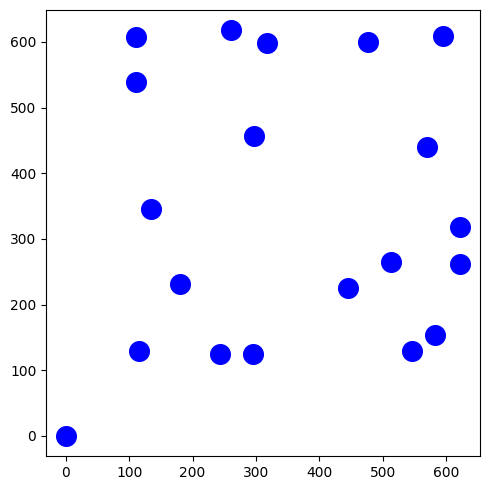

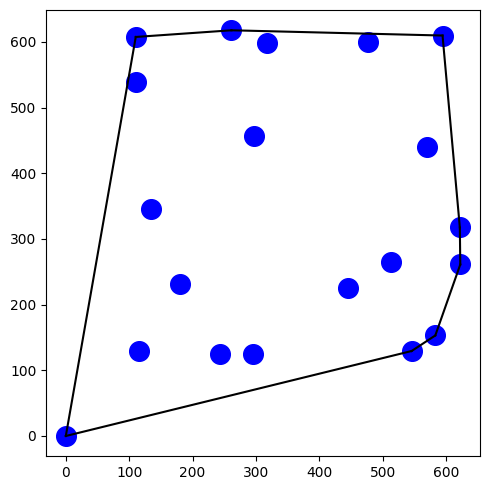

294570.3788641806


array([[  0.        ,   0.        ],
       [229.66058307, 534.00961867],
       [600.92986416, 481.11348826],
       [347.97704518, 118.27011781],
       [560.74323924, 224.60730291],
       [605.21874067, 105.75259595],
       [455.36985184, 348.90406168],
       [438.50529753, 566.71809917],
       [139.46651153, 390.66592258],
       [124.31515179, 280.54228321],
       [243.30031527, 125.47558839],
       [238.93653847, 258.14215984],
       [314.10432165, 602.10416492],
       [108.94349157, 609.71969016],
       [549.14313828, 155.82163398],
       [115.00026281, 129.42247359],
       [280.39638406, 356.02583974],
       [621.15647524, 601.42471128],
       [497.53950879, 105.68536174],
       [113.0649198 , 495.52927067]])

In [81]:
populations = initialize_populations()
best_layout = run_genetic_algorithm(populations)  # Get only the best layout
plot_best_layout(best_layout)  # Plot only the best layout
plot_best_layouts(best_layout)
print(calculate_enclosed_area(best_layout))
len(best_layout)

def get_gen1_populations():
    gen_1_pop = []
    for _ in range(40):
        best_layout = run_genetic_algorithm(populations)
        gen_1_pop.append(best_layout)
    return gen_1_pop

gen_1_pop = get_gen1_populations()
gen_1_pop[0]

In [82]:
# def find_ct(c_p):
#     ct = c_p  # Initial guess
#     epsilon = 1e-6  # Tolerance for convergence

#     while True:
#         new_ct = (ct + ct * (1 - ct)**0.5) / 2
#         if abs(new_ct - ct) < epsilon:
#             break
#         ct = new_ct

#     return ct

# # Find Ct for Cp = 0.1, 0.3, 0.41
# cp_values = [0.1, 0.3, 0.41]

# for cp in cp_values:
#     ct_result = find_ct(cp)
#     print(f"For Cp = {cp}, Ct = {ct_result}")


  ### Floris Initailization

In [83]:
fi_nrel = FlorisInterface('./gch.yaml')
fi_vestas = FlorisInterface('./gch_vestas.yaml')

In [88]:
def powers(fi, layout):
    power_list = []
    fi.reinitialize(
        layout_x=layout[:, 0],
        layout_y=layout[:, 1],
        wind_directions=wd_array,
        wind_speeds=ws_array,
    )

    aep = fi.get_farm_AEP(
        freq=freq,
        cut_in_wind_speed=4.0,  # Wakes are not evaluated below this wind speed
        cut_out_wind_speed=25.0,  # Wakes are not evaluated above this wind speed
    )
    power_list.append(round((aep / 1.0e9), 3))
    return power_list


# nrel_p1_powers[]
# populations = initialize_populations()
gen_1_pop = get_gen1_populations()

for layout in gen_1_pop:
    nrel_p1_powers = powers(fi_nrel, layout)
    print(nrel_p1_powers)

# for _ in range(len(populations)):
#     nrel_p1_powers = powers(fi_nrel, populations[_])
#     print(nrel_p1_powers)
# nrel_p1_powers = powers(fi_nrel, gen_1_pop[0])
# nrel_p1_powers

ValueError: A value (-0.9757658068119648) in x_new is below the interpolation range's minimum value (0.0).

In [ ]:


gen_2 = []
while len(gen_2) < 3:
    try:
        best_layout = run_genetic_algorithm(populations)
        nrel_p1_powers = powers(fi_nrel, best_layout)
        if nrel_p1_powers[2] < 20:
            gen_2.append(best_layout)
    except Exception as e:
        print(f"An error occurred: {e}")
        continue

len(gen_2)

/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)


/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake

An error occurred: 'DataFrame' object has no attribute 'append'


/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake

An error occurred: 'DataFrame' object has no attribute 'append'


...

An error occurred: 'DataFrame' object has no attribute 'append'


/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake

An error occurred: 'DataFrame' object has no attribute 'append'


/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake

3

In [ ]:
print(powers(fi_nrel, gen_2[0]))
print(powers(fi_nrel, gen_2[1]))
print(powers(fi_nrel, gen_2[2]))

[62.255, 74.552, 16.495]
[60.634, 74.552, 18.669]
[60.228, 74.552, 19.213]


In [ ]:
# print(gen_2[0])
# print(gen_2[1])
# print(gen_2[2])

In [ ]:
populations.to_csv('populations_0.csv')

AttributeError: 'list' object has no attribute 'to_csv'

In [ ]:
gen_2[0].to_csv('v1.csv')
gen_2[1].to_csv('v2.csv')
gen_2[2].to_csv('v3.csv')

In [21]:
power_outputs = []
for layout in gen_1_pop:
    power_output = powers(fi_nrel, layout)
    power_outputs.append(power_output)

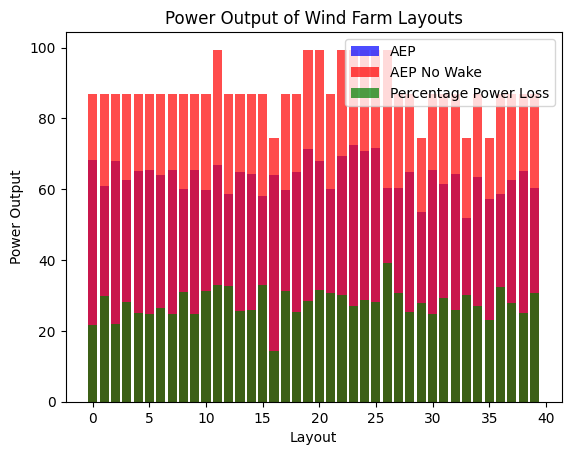

In [22]:
import matplotlib.pyplot as plt

# Assuming power_outputs is a list of lists, where each sublist is [aep, aep_no_wake, percentage_power_loss]
aep_values = [output[0] for output in power_outputs]
aep_no_wake_values = [output[1] for output in power_outputs]
percentage_power_loss_values = [output[2] for output in power_outputs]

# Create a new figure
plt.figure()

# Create a bar plot for aep values
plt.bar(range(len(aep_values)), aep_values, color='b', alpha=0.7, label='AEP')

# Create a bar plot for aep_no_wake values
plt.bar(range(len(aep_no_wake_values)), aep_no_wake_values, color='r', alpha=0.7, label='AEP No Wake')

# Create a bar plot for percentage_power_loss values
plt.bar(range(len(percentage_power_loss_values)), percentage_power_loss_values, color='g', alpha=0.7, label='Percentage Power Loss')

# Add labels and title
plt.xlabel('Layout')
plt.ylabel('Power Output')
plt.title('Power Output of Wind Farm Layouts')
plt.legend()

# Show the plot
plt.show()